In [ ]:
!pip install mxnet-mkl==1.6.0 numpy==1.23.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 MB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 85.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chex 0.1.86 requires numpy>=1.24.1, but you have numpy 1.23.1 which is incompatible.
pandas-stubs 2.0.3.230814 requires numpy>=1.25.0; python_version >= "3.9", but you have numpy 1.23.1 which is incompatible.
tensorflow 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 1.23.1 which is incompatible.


In [ ]:
!pip install gluonts

In [ ]:
import pandas as pd
import numpy as np
from gluonts.dataset.common import ListDataset
from gluonts.mx.trainer import Trainer
from gluonts.mx.model.deepar import DeepAREstimator


/usr/local/lib/python3.10/dist-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [ ]:
import yfinance as yf
ticker = "AAPL"  # Apple Inc.
start_date = "2010-01-01"
end_date = "2023-07-11"  # Update this to the current date

df = yf.download(ticker, start=start_date, end=end_date)


[*********************100%%**********************]  1 of 1 completed


In [ ]:
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,7.622500,7.660714,7.585000,7.643214,6.461978,493729600
2010-01-05,7.664286,7.699643,7.616071,7.656429,6.473148,601904800
2010-01-06,7.656429,7.686786,7.526786,7.534643,6.370185,552160000
2010-01-07,7.562500,7.571429,7.466071,7.520714,6.358409,477131200
2010-01-08,7.510714,7.571429,7.466429,7.570714,6.400680,447610800
...,...,...,...,...,...,...
2023-07-03,193.779999,193.880005,191.759995,192.460007,191.443314,31458200
2023-07-05,191.570007,192.979996,190.619995,191.330002,190.319260,46920300
2023-07-06,189.839996,192.020004,189.199997,191.809998,190.796722,45094300


In [ ]:
data = df['Close'].values

In [ ]:
train_data = ListDataset(
    [{"start": df.index[0], "target": df['Close'].values[:-30]}],
    freq="D"
)

test_data = ListDataset(
    [{"start": df.index[0], "target": df['Close'].values}],
    freq="D"
)

In [ ]:
from gluonts.mx.trainer import Trainer
from gluonts.mx.model.deepar import DeepAREstimator

# Create and train the DeepAR model
estimator = DeepAREstimator(
    freq="D",
    prediction_length=30,  # Forecasting the next 30 days
    trainer=Trainer(epochs=100)
)

predictor = estimator.train(training_data=train_data)


100%|██████████| 50/50 [00:07<00:00,  6.25it/s, epoch=100/100, avg_epoch_loss=0.901]


In [ ]:
import matplotlib.pyplot as plt
from gluonts.evaluation import Evaluator
from gluonts.evaluation.backtest import make_evaluation_predictions


In [ ]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_data,  # test dataset
    predictor=predictor,  # predictor
    num_samples=100  # number of sample paths we want for evaluation
)


In [ ]:
forecasts = list(forecast_it)
tss = list(ts_it)

In [ ]:
import json
evaluator = Evaluator()
agg_metrics, item_metrics = evaluator(iter(tss), iter(forecasts), num_series=len(test_data))

print(json.dumps(agg_metrics, indent=4))

Running evaluation: 100%|██████████| 1/1 [00:00<00:00, 28.03it/s]

{
    "MSE": 254.78087565104167,
    "abs_error": 426.02008056640625,
    "abs_target_sum": 5527.810546875,
    "abs_target_mean": 184.2603515625,
    "seasonal_error": 0.7489116544185831,
    "MASE": 18.961741706687977,
    "MAPE": 0.07613928318023681,
    "sMAPE": 0.07976115544637044,
    "MSIS": 73.97225745224132,
    "num_masked_target_values": 0.0,
    "QuantileLoss[0.1]": 185.74933471679688,
    "Coverage[0.1]": 0.0,
    "QuantileLoss[0.2]": 305.2415588378907,
    "Coverage[0.2]": 0.0,
    "QuantileLoss[0.3]": 372.2531341552734,
    "Coverage[0.3]": 0.0,
    "QuantileLoss[0.4]": 417.2262939453126,
    "Coverage[0.4]": 0.0,
    "QuantileLoss[0.5]": 426.02012634277344,
    "Coverage[0.5]": 0.0,
    "QuantileLoss[0.6]": 396.8754089355469,
    "Coverage[0.6]": 0.0,
    "QuantileLoss[0.7]": 321.88175964355463,
    "Coverage[0.7]": 0.03333333333333333,
    "QuantileLoss[0.8]": 211.51574096679687,
    "Coverage[0.8]": 0.2,
    "QuantileLoss[0.9]": 63.849484252929685,
    "Coverage[0.9]"

<Figure size 1000x700 with 0 Axes>

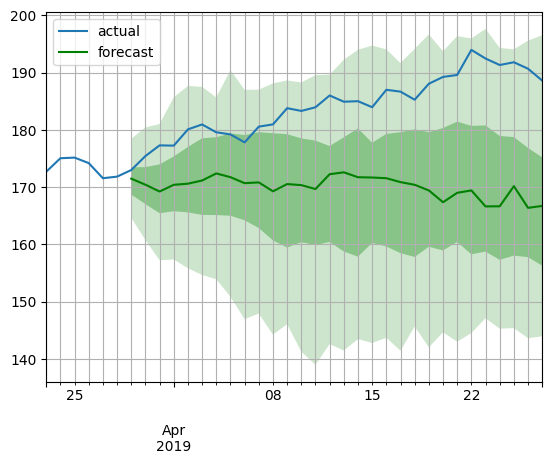

In [ ]:
for i in range(len(test_data)):
    ts_entry = tss[i]
    forecast_entry = forecasts[i]

    plt.figure(figsize=(10, 7))
    ts_entry[-36:].plot(label="target")
    forecast_entry.plot(color='g')
    plt.legend(["actual", "forecast"])
    plt.grid(which='both')
    plt.show()